In [101]:
import numpy as np
import pandas as pd
import os
from scipy.stats import expon, uniform, beta

from tqdm import tqdm
from joblib import cpu_count
import networkx as nx
import pickle
import matplotlib.pyplot as plt
from collections import Counter

from InfluenceDiffusion.estimation_models.OptimEstimation import GLTWeightEstimator, GLTWeightDistribEstimator
from InfluenceDiffusion.weight_samplers import make_random_weights_with_indeg_constraint, make_weighted_cascade_weights
from InfluenceDiffusion.influence_models import LTM, GLTM
from InfluenceDiffusion.Graph import Graph
from InfluenceDiffusion.Trace import Trace, Traces


print("CPUs available", cpu_count())

CPUs available 8


In [4]:

def compute_test_nll_history(fitted_estim: GLTWeightDistribEstimator, test_traces):
    fitted_estim._pre_fit(test_traces)
    vertex_2_test_nll_history = {v: [] for v in fitted_estim.informative_vertices}
    for vertex in fitted_estim.informative_vertices:
        weight_history = fitted_estim.weights_history_[vertex]
        distrib_param_history = fitted_estim.distrib_param_history_[vertex]
        for pred_weights, distrib_params in zip(weight_history, distrib_param_history):
            pred_distrib = fitted_estim._make_distrib(distrib_params)
            nll = fitted_estim._compute_normalized_vertex_nll(vertex=vertex, weights=pred_weights, distrib=pred_distrib)
            vertex_2_test_nll_history[vertex].append(nll) 
    return vertex_2_test_nll_history   

def compute_test_nll(fitted_estim: GLTWeightEstimator, test_traces):
    fitted_estim._pre_fit(test_traces)
    vertex_2_test_nll = {}
    for vertex in fitted_estim.informative_vertices:
        pred_weights = fitted_estim.weights_[fitted_estim.graph.get_parents_mask(vertex)]
        assumed_distrib = fitted_estim.vertex_2_distrib[vertex]
        nll = fitted_estim._compute_normalized_vertex_nll(vertex=vertex, weights=pred_weights, distrib=assumed_distrib)
        vertex_2_test_nll[vertex] = nll
    return vertex_2_test_nll

In [ ]:
n_nodes = 100
init_k = 10
rewire_p = 0.2
n_traces = 2000
test_ratio = 0.25

random_state = 1
max_seed_size = 10
seed_size_range = list(range(1, max_seed_size + 1))




n_traces = 2000

max_alternate_iter = 30
tol = 0


In [8]:
g = nx.watts_strogatz_graph(n_nodes, k=init_k, p=rewire_p, seed=random_state)
g = Graph(g.edges)

weights = make_random_weights_with_indeg_constraint(g, indeg_ub=1, random_state=random_state)                       
g.set_weights(weights)

Counter(g.get_all_indegrees())

Counter({4: 25, 5: 25, 6: 21, 7: 11, 3: 9, 2: 3, 0: 2, 10: 2, 11: 1, 8: 1})

In [298]:
# g = Graph([[i, 0] for i in range(1, n_nodes + 1)])
# weights = make_random_weights_with_indeg_constraint(g, indeg_ub=1, random_state=random_seed)                       
# g.set_weights(weights)

In [9]:
    
def trace_train_test_split(traces: Traces, test_ratio):
    assert 1 >= test_ratio >= 0
    length_sorted_traces = np.array(sorted(traces, key=lambda trace: len(trace.get_all_activated_vertices())),
                                    dtype=object)
    indices = np.arange(len(traces))
    test_indices = indices[::int(1 / test_ratio)]
    train_indices = list(set(indices) - set(test_indices))
    return list(length_sorted_traces[train_indices]), list(length_sorted_traces[test_indices])

In [108]:
np.random.seed(random_state)
max_ab = 5
true_as = np.random.randint(1, max_ab + 1, size=n_nodes)
true_bs = np.random.randint(1, max_ab + 1, size=n_nodes)
vertex_2_threshold_generator = {v: beta(a, b) for v, (a, b) in enumerate(zip(true_as, true_bs))}

gltm = GLTM(g, threshold_distribs=vertex_2_threshold_generator, random_state=random_state)
traces = gltm.sample_traces(n_traces, seed_size_range=seed_size_range)

train_traces, test_traces = trace_train_test_split(traces, test_ratio=test_ratio)

In [109]:
def line_connected_boxplot(list1, list2, xlabels=None, ylabel=None):
    plt.boxplot(
        [list1, list2],
        positions=[0, 1],
        widths=0.5
    )
    if xlabels is not None:
        plt.xticks([0, 1], xlabels)
    # Connect paired points
    for y1, y2 in zip(list1, list2):
        plt.plot([0, 1], [y1, y2], marker="o", alpha=0.3, color="grey")
    
    if ylabel is not None:
        plt.ylabel(ylabel)
    
    plt.tight_layout()


In [110]:
init_weights = make_weighted_cascade_weights(g)

## Stability to weight initialization

In [ ]:
gltm_estim_ab_oracle = GLTWeightDistribEstimator(g, distrib_family=beta, 
                                                 distrib_params_2_range={"a": (1, 10), "b": (1, 10)})

# golden standard is estimator initialized with true weights
gltm_estim_ab_oracle.fit(train_traces, init_weights=g.weights, max_alternate_iter=max_alternate_iter, tol=0)

In [113]:
n_inits = 10
rs_range = range(random_state + 1, random_state + n_inits + 1)
vertex_param_histories_over_rs = []
vertex_weight_histories_over_rs = []
vertex_nll_histories_over_rs = []

gltm_estim_ab = GLTWeightDistribEstimator(g, distrib_family=beta, 
                                          distrib_params_2_range={"a": (1, 10), "b": (1, 10)})

for rs in tqdm(rs_range):
    init_weights = make_random_weights_with_indeg_constraint(g, indeg_ub=1, random_state=rs)
    gltm_estim_ab.fit(train_traces, init_weights=init_weights, max_alternate_iter=max_alternate_iter, tol=tol)
    vertex_param_histories_over_rs.append(gltm_estim_ab.distrib_param_history_)
    vertex_weight_histories_over_rs.append(gltm_estim_ab.weights_history_)
    vertex_nll_histories_over_rs.append(gltm_estim_ab.nll_history_)

100%|██████████| 10/10 [05:10<00:00, 31.09s/it]


In [2]:
def RMAE(y_true, y_pred, axis=None):
    return np.linalg.norm(y_true - y_pred, ord=1, axis=axis) / np.linalg.norm(y_true, ord=1, axis=axis)

In [114]:
def plot_convergence(
    true_values,
    pred_values,
    xlab="Alternating iteration",
    ylab="Relative MAE",
    metric=RMAE,
    n_std=2,
    ax=None,
    fontsize=12,
):
    """
    Plot mean error with confidence bounds across iterations.

    Parameters
    ----------
    true_values : array-like of shape (n_features,)
        Ground-truth values.

    pred_values : array-like of shape
        (n_replications, n_iterations, n_features)
        Predicted values across replications and iterations.

    metric : callable
        Metric supporting an ``axis`` argument, such as RMAE.

    n_std : float
        Number of standard deviations used for the bounds.

    ax : matplotlib.axes.Axes, optional
        Axes on which to draw the plot.

    Returns
    -------
    matplotlib.axes.Axes
    """
    true_values = np.asarray(true_values)
    pred_values = np.asarray(pred_values)

    if true_values.ndim != 1:
        raise ValueError(
            "true_values must have shape (n_features,)."
        )

    if pred_values.ndim != 3:
        raise ValueError(
            "pred_values must have shape "
            "(n_replications, n_iterations, n_features)."
        )

    if pred_values.shape[2] != true_values.shape[0]:
        raise ValueError(
            "The n_features dimension of pred_values must match "
            "the length of true_values."
        )

    # Shape: (n_replications, n_iterations)
    errors = np.apply_along_axis(
        lambda y_pred: metric(true_values, y_pred),
        axis=-1,
        arr=pred_values,
    )

    # Aggregate across replications.
    mean_error = np.mean(errors, axis=0)
    std_error = np.std(errors, axis=0)

    lower = mean_error - n_std * std_error
    upper = mean_error + n_std * std_error

    iterations = np.arange(1, pred_values.shape[1] + 1)

    if ax is None:
        _, ax = plt.subplots()

    ax.plot(iterations, mean_error, marker="o")
    ax.fill_between(iterations, lower, upper, alpha=0.25)

    ax.set_xlabel(xlab, fontsize=fontsize)
    ax.set_ylabel(ylab, fontsize=fontsize)
    ax.tick_params(axis='both', which='major', labelsize=fontsize)

    return ax

In [153]:
fitted_params_df = pd.DataFrame(gltm_estim_ab_oracle.get_fitted_threshold_distrib_params()).T
filter_cond = lambda v: g.get_indegree(v) >= 3 

node_sample = [v for v in gltm_estim_ab_oracle.informative_vertices if filter_cond(v)]

fitted_params_df.loc[node_sample].boxplot(figsize=(6, 4))

<Axes: >

In [154]:
oracle_pred_weights = np.hstack([gltm_estim_ab_oracle.weights_[g.get_parents_mask(v)] for v in node_sample])
oracle_pred_distrib_params = gltm_estim_ab_oracle.get_fitted_threshold_distrib_params()
oracle_pred_as = np.hstack([oracle_pred_distrib_params[v]["a"] for v in node_sample])  
oracle_pred_bs = np.hstack([oracle_pred_distrib_params[v]["b"] for v in node_sample])  

In [155]:
a_histories_over_rs = [[np.hstack([param_hists_over_vertices[v][iteration][0] for v in node_sample])
                        for iteration in range(max_alternate_iter)] 
                       for param_hists_over_vertices in vertex_param_histories_over_rs]
b_histories_over_rs = [[np.hstack([param_hists_over_vertices[v][iteration][1] for v in node_sample])
                        for iteration in range(max_alternate_iter)] 
                       for param_hists_over_vertices in vertex_param_histories_over_rs]
weight_histories_over_rs = [[np.hstack([weight_hist[v][iteration] for v in node_sample]) 
                            for iteration in range(max_alternate_iter)]
                           for weight_hist in vertex_weight_histories_over_rs]


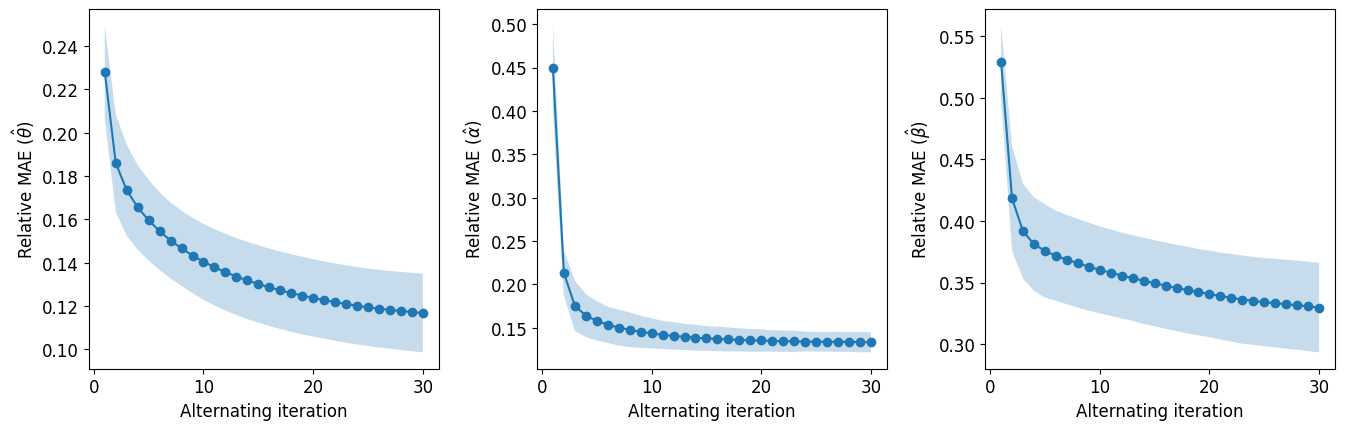

In [157]:
fig, axs = plt.subplots(1, 3, figsize=(14, 5))
fig.tight_layout(pad=4.0)


plot_convergence(
    true_values=oracle_pred_weights,
    pred_values=np.stack(weight_histories_over_rs),
    ax=axs[0],
    ylab=r"Relative MAE ($\hat{\theta}$)"
)

plot_convergence(
    true_values=oracle_pred_as,
    pred_values=np.stack(a_histories_over_rs),
    ax=axs[1],
    ylab=r"Relative MAE ($\hat{\alpha}$)"
)

plot_convergence(
    true_values=oracle_pred_bs,
    pred_values=np.stack(b_histories_over_rs),
    ax=axs[2],
    ylab=r"Relative MAE ($\hat{\beta}$)"
)

plt.show()

## Statistical properties of joint estimator

In [147]:
def compute_new_parent_appearence_times_in_trace(trace: Trace):
    informative_vs = trace.get_all_failed_and_activated_vertices_no_seed()
    activ_time_dict = trace.get_activation_time_dict()
    v_2_new_parent_times = {}
    for v in informative_vs:
        
        v_time = activ_time_dict[v] if v in activ_time_dict else np.inf
        active_parents = set(trace.graph.get_parents(v)).intersection(activ_time_dict)
        new_parent_appearence_times = set([activ_time_dict[u] for u in active_parents if activ_time_dict[u] < v_time])
        v_2_new_parent_times[v] = new_parent_appearence_times
    return v_2_new_parent_times

def compute_vertex_sample_size(traces: Traces):
    v_2_total_appearences = {v: 0 for v in traces[0].graph.get_sinks()}
    v_2_num_informative_traces = {v: 0 for v in traces[0].graph.get_sinks()}
    for trace in traces:
        v_2_new_parent_times = compute_new_parent_appearence_times_in_trace(trace)
        for v, new_parent_times in v_2_new_parent_times.items():
            v_2_total_appearences[v] += len(new_parent_times)
            v_2_num_informative_traces[v] += 1
    return v_2_total_appearences, v_2_num_informative_traces



vertex_2_indeg = dict(zip(g.get_vertices(), g.get_all_indegrees()))
vertex_2_train_size, vertex_2_n_inform_traces = compute_vertex_sample_size(train_traces)

In [ ]:


vertex_2_nll_improvement_ratio = {v: gltm_estim_ab.nll_history_[v][-1] / gltm_estim_ab.nll_history_[v][0]
                            for v in gltm_estim_ab.informative_vertices}
vertex_2_nll_improvement = {v: gltm_estim_ab.nll_history_[v][0] - gltm_estim_ab.nll_history_[v][-1]
                            for v in gltm_estim_ab.informative_vertices}
vertex_2_nll_final = {v: gltm_estim_ab.nll_history_[v][-1] for v in gltm_estim_ab.informative_vertices}




In [ ]:


def report_individual_node_results(
    node_sample,
    fitted_estim: GLTWeightDistribEstimator,
    fontsize=12,
    figsize=None,
    weight_error_metric=RMAE,
    metric_name="Relative MAE",
    colormap="turbo",
):
    from matplotlib import colormaps
    from matplotlib.ticker import MaxNLocator

    node_sample = list(node_sample)
    n_nodes = len(node_sample)
    n_params = len(fitted_estim.distrib_param_names)
    n_axes = 1 + n_params

    if n_nodes == 0:
        raise ValueError("node_sample must contain at least one node.")

    if figsize is None:
        figsize = (5.2 * n_axes, 5.5)

    fig, axs = plt.subplots(
        1,
        n_axes,
        figsize=figsize,
        squeeze=False,
        constrained_layout=True,
    )
    axs = axs.ravel()

    graph = fitted_estim.graph

    # Evenly sample a continuous colormap so colors do not repeat.
    cmap = colormaps[colormap]
    color_positions = np.linspace(0.03, 0.97, n_nodes)
    node_colors = {
        vertex: cmap(position)
        for vertex, position in zip(node_sample, color_positions)
    }

    line_width = 2.0 if n_nodes <= 15 else 1.6
    line_alpha = 0.95 if n_nodes <= 15 else 0.85

    def style_axis(ax):
        ax.set_facecolor("#fafafa")
        ax.grid(
            True,
            linestyle="--",
            linewidth=0.7,
            alpha=0.35,
        )
        ax.set_axisbelow(True)
        ax.tick_params(axis="both", labelsize=fontsize - 1)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_alpha(0.5)
        ax.spines["bottom"].set_alpha(0.5)

    # Weight-estimation errors.
    error_ax = axs[0]

    for vertex in node_sample:
        parent_weights = graph.weights[
            graph.get_parents_mask(vertex)
        ]

        weight_errs = [
            weight_error_metric(parent_weights, predicted_weights)
            for predicted_weights
            in fitted_estim.weights_history_[vertex]
        ]

        iterations = np.arange(1, len(weight_errs) + 1)

        error_ax.plot(
            iterations,
            weight_errs,
            color=node_colors[vertex],
            linewidth=line_width,
            alpha=line_alpha,
        )

    error_ax.set_ylabel(
        rf"{metric_name} ($\hat{{\theta}}_v$)",
        fontsize=fontsize,
    )
    error_ax.set_xlabel(
        "Alternating Iteration",
        fontsize=fontsize,
    )
    style_axis(error_ax)

    # Distribution-parameter histories.
    for param_index, param_name in enumerate(
        fitted_estim.distrib_param_names
    ):
        ax = axs[param_index + 1]

        for vertex in node_sample:
            parameter_history = np.asarray(
                fitted_estim.distrib_param_history_[vertex]
            )

            values = parameter_history[:, param_index]
            iterations = np.arange(1, len(values) + 1)

            ax.plot(
                iterations,
                values,
                color=node_colors[vertex],
                linewidth=line_width,
                alpha=line_alpha,
            )

        ax.axhline(
            param_name_2_true_value[param_name],
            color="black",
            linestyle=(0, (5, 4)),
            linewidth=1.8,
            alpha=0.8,
            zorder=1,
            label="True value"
        )

        ax.set_ylabel(param_name_2_axis_name[param_name], fontsize=fontsize)
        ax.set_xlabel(
            "Alternating Iteration",
            fontsize=fontsize,
        )
        style_axis(ax)
        ax.legend(fontsize=fontsize, loc="lower right")

    return fig, axs


In [100]:
a, b = 2, 3
param_name_2_true_value = {"a": a, "b": b}
param_name_2_axis_name = {"a": r'$\hat{\alpha}_v$', "b": r'$\hat{\beta}_v$'}
threshold_generator = beta(a, b)

gltm = LTM(g, threshold_generator=threshold_generator, random_state=random_state)
traces = gltm.sample_traces(n_traces, seed_size_range=seed_size_range)

train_traces, test_traces = trace_train_test_split(traces, test_ratio=test_ratio)

Sample size: 7


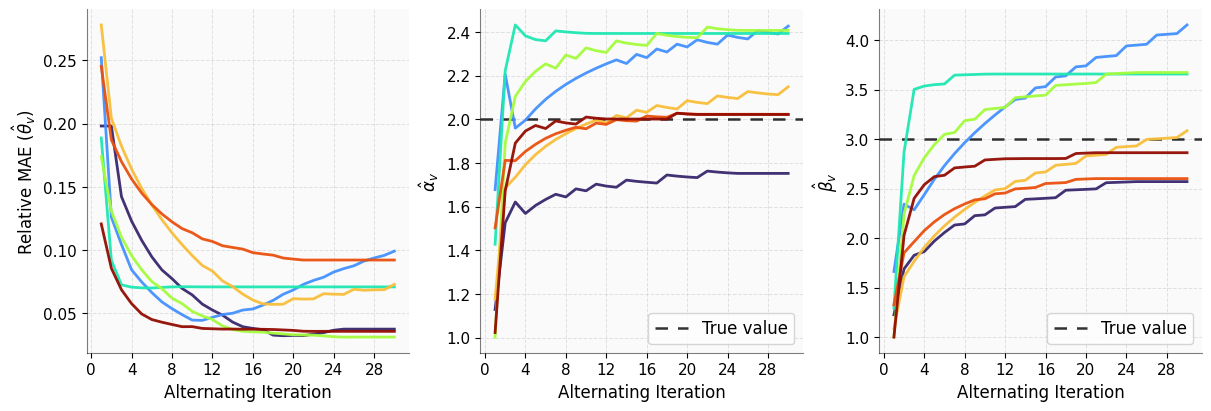

In [527]:
filter_cond = lambda v: (g.get_indegree(v) > 4  and 
                         gltm_estim_ab.nll_history_[v][-1] / gltm_estim_ab.nll_history_[v][0] < 0.95)
node_sample = [v for v in gltm_estim_ab.informative_vertices if filter_cond(v)]
print("Sample size:", len(node_sample))

report_individual_node_results(node_sample, gltm_estim_ab, figsize=(12, 4), 
                               weight_error_metric=RMAE, metric_name="Relative MAE")
plt.show()

In [515]:
def report_average_node_results(
    node_sample,
    fitted_estim: GLTWeightDistribEstimator,
    fontsize=12,
    figsize=None,
    weight_error_metric=RMAE,
    metric_name="Relative MAE",
    n_std=1.0,
    plot_train_nll=False,
    mean_color="tab:blue",
    fill_alpha=0.2,
):
    """
    Plot average convergence trends across nodes.

    Each panel shows:
        - the node-wise mean as a solid line,
        - mean ± n_std * std as dashed bounding lines,
        - the area between the bounds as a shaded region.

    Weight convergence is always plotted first. Train NLL convergence can
    optionally be plotted as the final panel.

    Parameters
    ----------
    node_sample
        Iterable of nodes included in the aggregation.

    fitted_estim
        Fitted GLTWeightDistribEstimator instance.

    fontsize
        Base font size for labels and ticks.

    figsize
        Figure size. If None, it is determined from the number of panels.

    weight_error_metric
        Function comparing true and estimated parent weights.

    metric_name
        Display name of the weight-error metric.

    n_std
        Number of standard deviations used for the bounds.

    plot_train_nll
        Whether to add a final Train NLL convergence panel using
        fitted_estim.nll_history_.

    mean_color
        Color used for the mean, bounds, and shaded region.

    fill_alpha
        Opacity of the shaded standard-deviation region.

    Returns
    -------
    fig, axs
        Matplotlib figure and one-dimensional array of axes.
    """
    from matplotlib.ticker import MaxNLocator

    node_sample = list(node_sample)
    n_nodes = len(node_sample)
    n_params = len(fitted_estim.distrib_param_names)

    # Weights are always plotted.
    n_axes = 1 + n_params + int(plot_train_nll)

    if n_nodes == 0:
        raise ValueError("node_sample must contain at least one node.")

    if n_std < 0:
        raise ValueError("n_std must be non-negative.")

    if figsize is None:
        figsize = (5.2 * n_axes, 5.5)

    fig, axs = plt.subplots(
        1,
        n_axes,
        figsize=figsize,
        squeeze=False,
        constrained_layout=True,
    )
    axs = axs.ravel()

    graph = fitted_estim.graph

    def style_axis(ax):
        ax.set_facecolor("#fafafa")
        ax.grid(
            True,
            linestyle="--",
            linewidth=0.7,
            alpha=0.35,
        )
        ax.set_axisbelow(True)
        ax.tick_params(
            axis="both",
            labelsize=max(fontsize - 1, 1),
        )
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_alpha(0.5)
        ax.spines["bottom"].set_alpha(0.5)

    def pad_histories(histories):
        """
        Pad histories with NaN so histories of different lengths can be
        aggregated iteration by iteration.
        """
        if not histories:
            raise ValueError("At least one history is required.")

        histories = [
            np.asarray(history, dtype=float).reshape(-1)
            for history in histories
        ]

        max_length = max(len(history) for history in histories)

        if max_length == 0:
            raise ValueError("Histories must contain at least one value.")

        padded = np.full(
            (len(histories), max_length),
            np.nan,
            dtype=float,
        )

        for row_index, history in enumerate(histories):
            padded[row_index, :len(history)] = history

        return padded

    def calculate_mean_and_bounds(
        histories,
        crop_lower_at_zero=False,
    ):
        values = pad_histories(histories)

        mean = np.nanmean(values, axis=0)
        std = np.nanstd(values, axis=0)

        lower = mean - n_std * std
        upper = mean + n_std * std

        if crop_lower_at_zero:
            lower = np.maximum(lower, 0.0)

        return mean, lower, upper

    def plot_mean_with_band(
        ax,
        histories,
        crop_lower_at_zero=False,
    ):
        """
        Plot the mean and standard-deviation band.

        Returns
        -------
        iterations
            The exact x coordinates used by the mean and filled region.
        """
        mean, lower, upper = calculate_mean_and_bounds(
            histories,
            crop_lower_at_zero=crop_lower_at_zero,
        )

        iterations = np.arange(1, len(mean) + 1)

        ax.fill_between(
            iterations,
            lower,
            upper,
            color=mean_color,
            alpha=fill_alpha,
            linewidth=0,
            zorder=1,
        )

        ax.plot(
            iterations,
            lower,
            color=mean_color,
            linestyle="--",
            linewidth=1.2,
            alpha=0.75,
            zorder=2,
        )

        ax.plot(
            iterations,
            upper,
            color=mean_color,
            linestyle="--",
            linewidth=1.2,
            alpha=0.75,
            zorder=2,
        )

        ax.plot(
            iterations,
            mean,
            color=mean_color,
            linewidth=2.5,
            zorder=3,
        )

        return iterations

    # ---------------------------------------------------------------
    # Weight-estimation error
    # ---------------------------------------------------------------
    weight_error_histories = []

    for vertex in node_sample:
        parent_weights = graph.weights[
            graph.get_parents_mask(vertex)
        ]

        weight_errors = [
            weight_error_metric(
                parent_weights,
                predicted_weights,
            )
            for predicted_weights
            in fitted_estim.weights_history_[vertex]
        ]

        weight_error_histories.append(weight_errors)

    error_ax = axs[0]

    plot_mean_with_band(
        error_ax,
        weight_error_histories,
        crop_lower_at_zero=True,
    )

    error_ax.set_ylabel(
        rf"{metric_name} ($\hat{{\theta}}_v$)",
        fontsize=fontsize,
    )
    error_ax.set_xlabel(
        "Alternating Iteration",
        fontsize=fontsize,
    )
    error_ax.set_ylim(bottom=0)
    style_axis(error_ax)

    # ---------------------------------------------------------------
    # Distribution-parameter histories
    # ---------------------------------------------------------------
    for param_index, param_name in enumerate(
        fitted_estim.distrib_param_names
    ):
        ax = axs[1 + param_index]
        parameter_histories = []

        for vertex in node_sample:
            vertex_history = np.asarray(
                fitted_estim.distrib_param_history_[vertex],
                dtype=float,
            )

            if vertex_history.ndim != 2:
                raise ValueError(
                    "Expected distrib_param_history_ for vertex "
                    f"{vertex} to be two-dimensional, but received "
                    f"shape {vertex_history.shape}."
                )

            if param_index >= vertex_history.shape[1]:
                raise ValueError(
                    f"Parameter index {param_index} is unavailable for "
                    f"vertex {vertex}; history shape is "
                    f"{vertex_history.shape}."
                )

            parameter_histories.append(
                vertex_history[:, param_index]
            )

        iterations = plot_mean_with_band(
            ax,
            parameter_histories,
            crop_lower_at_zero=False,
        )

        true_value = param_name_2_true_value[param_name]

        # Use the exact same x coordinates as the filled region.
        ax.plot(
            iterations,
            np.full(
                iterations.shape,
                true_value,
                dtype=float,
            ),
            color="black",
            linestyle=(0, (5, 4)),
            linewidth=1.8,
            alpha=0.8,
            zorder=4,
            label="True value",
        )

        ax.set_ylabel(
            param_name_2_axis_name[param_name],
            fontsize=fontsize,
        )
        ax.set_xlabel(
            "Alternating Iteration",
            fontsize=fontsize,
        )

        style_axis(ax)
        ax.legend(
            fontsize=fontsize,
            frameon=False,
        )

    # ---------------------------------------------------------------
    # Optional Train NLL panel
    # ---------------------------------------------------------------
    if plot_train_nll:
        if not hasattr(fitted_estim, "nll_history_"):
            raise AttributeError(
                "plot_train_nll=True, but fitted_estim does not have "
                "an nll_history_ attribute."
            )

        nll_histories = []

        for vertex in node_sample:
            try:
                vertex_nll_history = fitted_estim.nll_history_[vertex]
            except (KeyError, TypeError) as exc:
                raise ValueError(
                    "Expected fitted_estim.nll_history_ to contain a "
                    f"history for vertex {vertex}."
                ) from exc

            nll_histories.append(vertex_nll_history)

        nll_ax = axs[-1]

        plot_mean_with_band(
            nll_ax,
            nll_histories,
            crop_lower_at_zero=False,
        )

        nll_ax.set_ylabel(
            "Train NLL",
            fontsize=fontsize,
        )
        nll_ax.set_xlabel(
            "Alternating Iteration",
            fontsize=fontsize,
        )
        style_axis(nll_ax)

    return fig, axs

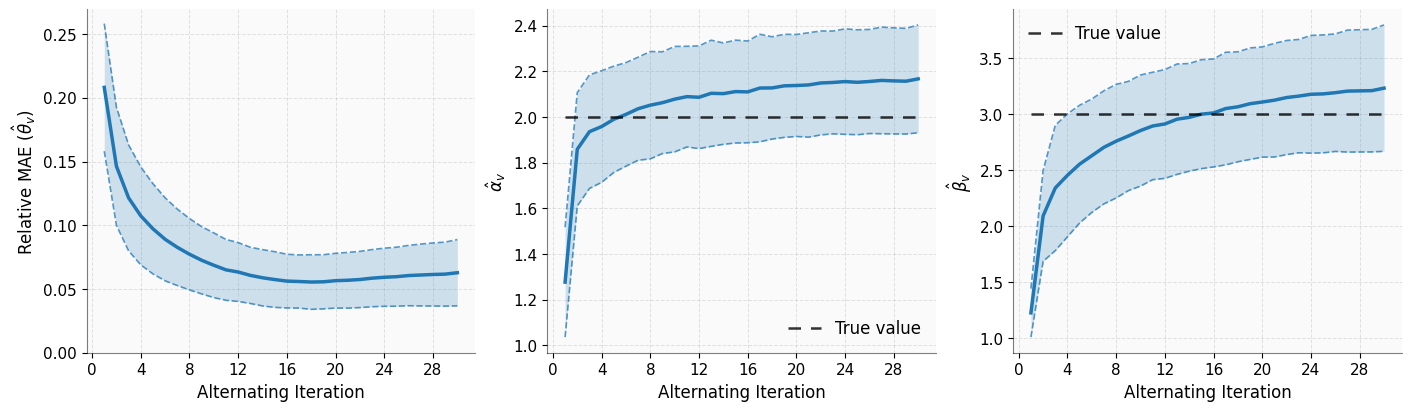

In [ ]:
filter_cond = lambda v: (g.get_indegree(v) > 4  and gltm_estim_ab.nll_history_[v][-1] / gltm_estim_ab.nll_history_[v][0] < 0.95)
node_sample = [v for v in gltm_estim_ab.informative_vertices if filter_cond(v)]

report_average_node_results(fitted_estim=gltm_estim_ab, node_sample=node_sample, n_std=1,  plot_train_nll=False,
                            figsize=(14, 4))
plt.show()

In [510]:
import pandas as pd 

info_table = pd.DataFrame(index=list(gltm_estim_ab.informative_vertices))
info_table["indegree"] = [vertex_2_indeg[v] for v in info_table.index]
info_table["train_size"] = [vertex_2_train_size[v] for v in info_table.index]
info_table["n_inform_traces"] = [vertex_2_n_inform_traces[v] for v in info_table.index]
info_table["nll_improvement"] = [vertex_2_nll_improvement[v] for v in info_table.index]
info_table["nll_final"] = [vertex_2_nll_final[v] for v in info_table.index]

In [511]:
info_table.corr().round(2)

,indegree,train_size,n_inform_traces,nll_improvement,nll_final
indegree,1.00,0.75,0.62,-0.01,0.10
train_size,0.75,1.00,0.95,0.10,0.24
n_inform_traces,0.62,0.95,1.00,0.11,0.26
nll_improvement,-0.01,0.10,0.11,1.00,0.03
nll_final,0.10,0.24,0.26,0.03,1.00


Sample size: 39


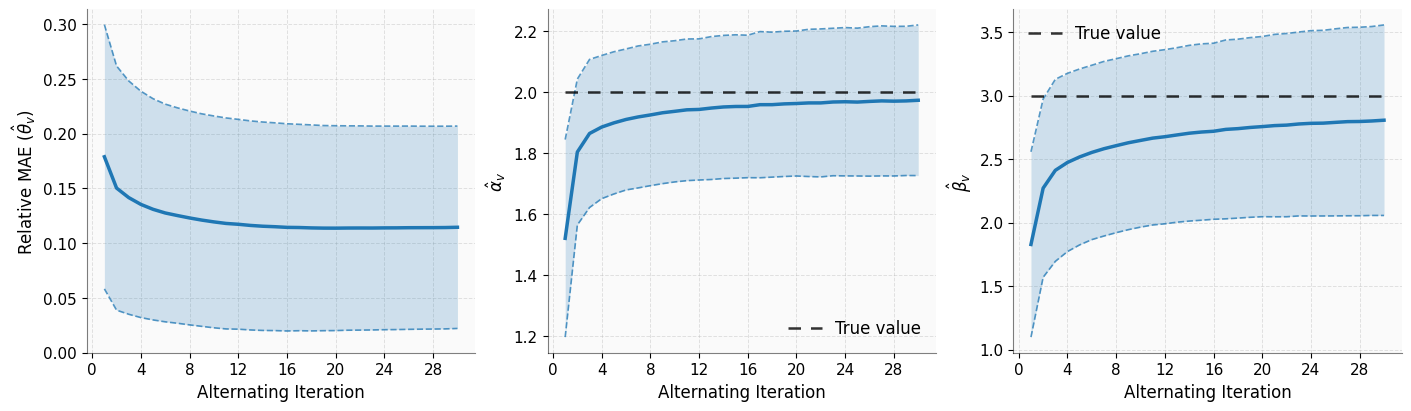

In [ ]:

filter_cond =  lambda v: g.get_indegree(v) > 4 and \
    vertex_2_n_inform_traces[v] >= np.quantile(list(vertex_2_n_inform_traces.values()), q=0.5) 
node_sample = [v for v in gltm_estim_ab.informative_vertices if filter_cond(v)]
print("Sample size:", len(node_sample))

report_average_node_results(fitted_estim=gltm_estim_ab, node_sample=node_sample, n_std=1, figsize=(14, 4))
plt.show()

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: xlabel='Alternating Iteration', ylabel='Relative MAE ($\\hat{\\theta}_v$)'>,
        <Axes: xlabel='Alternating Iteration', ylabel='$\\hat{\\alpha}$'>,
        <Axes: xlabel='Alternating Iteration', ylabel='$\\hat{\\beta}$'>],
       dtype=object))

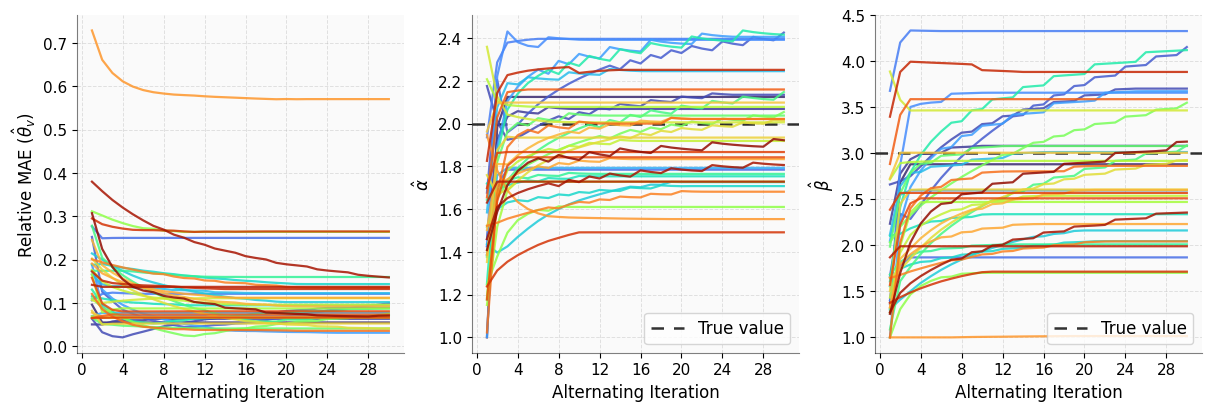

In [514]:

report_individual_node_results(node_sample, gltm_estim_ab, figsize=(12, 4), 
                               weight_error_metric=RMAE, metric_name="Relative MAE")